In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
from matplotlib.animation import PillowWriter
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [9]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [10]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.8, 0.4, 0.2) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)
m_g_array_rise_fall = rise_fall(t_array, 2, 8)
m_g_array_rise_fall /= np.trapezoid(m_g_array_rise_fall, t_array)

etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
#tau_stars = [0.5, 2, 6]
colors_lines = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']
colors_dots = ['greenyellow', 'cornflowerblue', 'orange', 'blue', 'red', 'yellow', 'green', 'gray', 'peru', 'navy']


gals_taustar_eta0 = []

for i in range(len(tau_stars)):
    gals_taustar_eta0.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))

g_cc_Fe = 4.73/13.7
g_Mn_ratio = 1.5
g_cc_Mns = [0.75 * g_cc_Fe, g_cc_Fe, g_cc_Fe * 1.5, g_cc_Fe * 2, g_cc_Fe * 3]
#g_cc_Mns = [0.75 * g_cc_Fe, g_cc_Fe, g_cc_Fe * 2]

gals_gcc_ep2 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            alpha_cc_Mn = 0.17,
            g_cc_Mn=g_cc_Mn,
            Epsilon=2
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

gals_gcc_ep2_alpha_cc_0 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            alpha_cc_Mn = 0,
            g_cc_Mn=g_cc_Mn,
            Epsilon=2
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

gals_gcc_ep2_alpha_cc_05 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            alpha_cc_Mn = 0.5,
            g_cc_Mn=g_cc_Mn,
            Epsilon=2
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

gals_gcc_ep2_alpha_cc_1 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            alpha_cc_Mn = 1,
            g_cc_Mn=g_cc_Mn,
            Epsilon=2
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]


gals_gcc_ep1 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            g_cc_Mn=g_cc_Mn,
            Epsilon=1
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

gals_gcc_ep1_5 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            g_cc_Mn=g_cc_Mn,
            Epsilon=1.5
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

In [11]:
gals_gcc_ep2_alpha_Ia_0 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            alpha_Ia_Mn = 0,
            g_cc_Mn=g_cc_Mn,
            Epsilon=2
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

gals_gcc_ep2_alpha_Ia_06 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            alpha_Ia_Mn = 0.6,
            g_cc_Mn=g_cc_Mn,
            Epsilon=2
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

gals_gcc_ep2_alpha_Ia_1 = [
    [
        evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_rise_fall,
            tau_star=tau,
            eta=etas[0],
            alpha_Ia_Mn = 1,
            g_cc_Mn=g_cc_Mn,
            Epsilon=2
        )
        for tau in tau_stars
    ]
    for g_cc_Mn in g_cc_Mns
]

In [12]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals

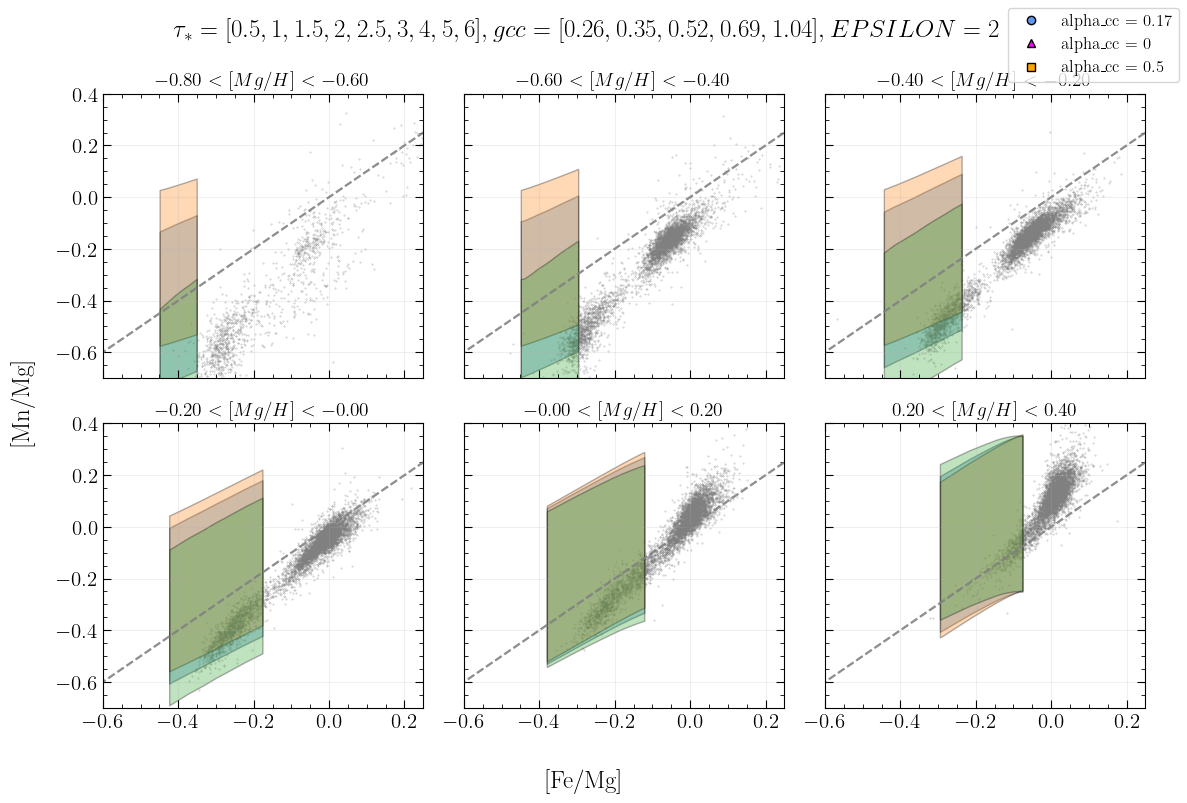

In [16]:
colors = ['black', 'blue', 'red', 'green', 'magenta']
#color_eps = ['black', 'red', 'blue']
color_eps = ['cornflowerblue', 'magenta', 'orange']
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

eps = [2, 2, 2, 2]
all_gals = [gals_gcc_ep2, gals_gcc_ep2_alpha_cc_0, gals_gcc_ep2_alpha_cc_05, gals_gcc_ep2_alpha_cc_1]
shapes = ['o', '^', 's', '*', 'd']
labels = ['alpha_cc = 0.17', 'alpha_cc = 0', 'alpha_cc = 0.5', 'alpha_cc = 1']

for which_ep, gals, color_ep, label in zip(eps, all_gals, color_eps, labels):
    # Compute endpoints for THIS epsilon set
    gals_endpoints = {
        j: find_endpoints(gals[j], mg_h_big_bin_centers)
        for j in range(len(gals))
    }

    for i, ax in enumerate(axes):

        # Background data
        df = downsample(data[data['MG_H_big_bin'] == i], 5000)
        ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color='gray', alpha = 0.2)

        # 1:1 line
        xs = np.linspace(-1, 1, 100)
        ax.plot(xs, xs, '--', alpha=0.5, color='gray')

        # τ_* sequences for all gcc values
        for j, (gals_j, endpoints_j, shape, gcc_val) in enumerate(
            zip(gals, gals_endpoints.values(), shapes, g_cc_Mns)
        ):
            idxs = endpoints_j[i]

            fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
            mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]

            if gcc_val == g_cc_Mns[0]:
                fe_mg_first = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
                mn_mg_first = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]

            elif gcc_val == g_cc_Mns[-1]:
                fe_mg_last = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
                mn_mg_last = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]
                ax.fill_between(fe_mg, mn_mg_first, mn_mg_last, alpha = 0.3, edgecolor='black', label = f"Eps = {which_ep}")

            #ax.plot(fe_mg, mn_mg, marker=shape,color=color_ep,markeredgecolor='black',markersize=7,label=label if j == 0 else "_nolegend_")

        if (i == 0) & (j == 0):
            ax.legend(fontsize=9)

        ax.set_title(
            rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
            fontsize=14
        )
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.60, 0.25)
        ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
gcc_rounds = [round(x, 2) for x in g_cc_Mns]
fig.suptitle(rf"$\tau_* = {tau_stars}, gcc = {gcc_rounds}, EPSILON = 2$")

legend_handles = [
    Line2D([0], [0], marker=shapes[i], color='w',
           markerfacecolor=color_eps[i], markeredgecolor='black',
           markersize=6, label=labels[i])
    for i in range(3)
]

fig.legend(handles=legend_handles, loc='upper right', fontsize=12)

plt.tight_layout()

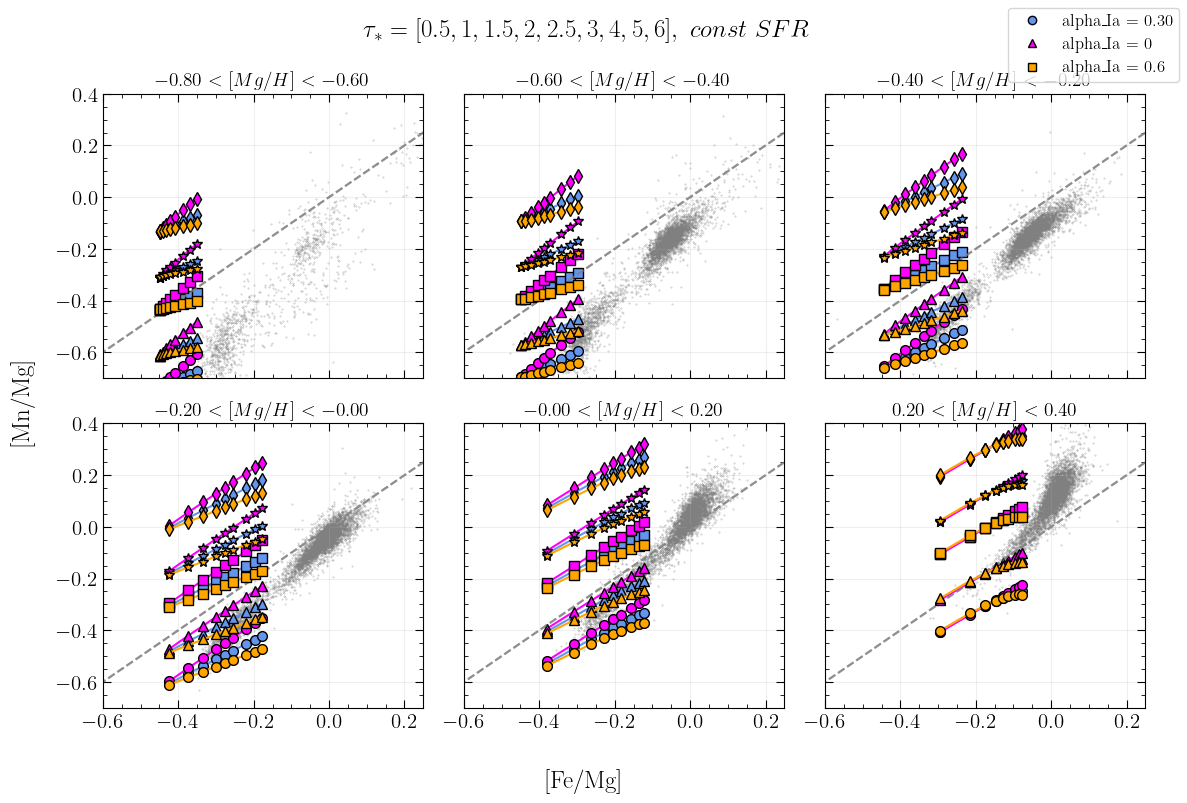

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

eps = [2, 2, 2, 2]
all_gals = [gals_gcc_ep2, gals_gcc_ep2_alpha_Ia_0, gals_gcc_ep2_alpha_Ia_06, gals_gcc_ep2_alpha_Ia_1]
shapes = ['o', '^', 's', '*', 'd']
labels = ['alpha_Ia = 0.30', 'alpha_Ia = 0', 'alpha_Ia = 0.6', 'alpha_Ia = 1']

for which_ep, gals, color_ep, label in zip(eps, all_gals, color_eps, labels):
    # Compute endpoints for THIS epsilon set
    gals_endpoints = {
        j: find_endpoints(gals[j], mg_h_big_bin_centers)
        for j in range(len(gals))
    }

    for i, ax in enumerate(axes):

        # Background data
        df = downsample(data[data['MG_H_big_bin'] == i], 5000)
        ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color='gray', alpha = 0.2)

        # 1:1 line
        xs = np.linspace(-1, 1, 100)
        ax.plot(xs, xs, '--', alpha=0.5, color='gray')

        # τ_* sequences for all gcc values
        for j, (gals_j, endpoints_j, shape, gcc_val) in enumerate(
            zip(gals, gals_endpoints.values(), shapes, g_cc_Mns)
        ):
            idxs = endpoints_j[i]

            fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
            mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]

            ax.plot(
                fe_mg, mn_mg, marker=shape,
                color=color_ep,
                markeredgecolor='black',
                markersize=7,
                label=label if j == 0 else "_nolegend_"
            )

        if (i == 0) & (j == 0):
            ax.legend(fontsize=9)

        ax.set_title(
            rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
            fontsize=14
        )
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.60, 0.25)
        ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")


legend_handles = [
    Line2D([0], [0], marker=shapes[i], color='w',
           markerfacecolor=color_eps[i], markeredgecolor='black',
           markersize=6, label=labels[i])
    for i in range(3)
]

fig.legend(handles=legend_handles, loc='upper right', fontsize=12)

plt.tight_layout()